## Анализ воронки регистраций

### 1. Подготовка данных в БД

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import seaborn as sns

In [2]:
data = pd.read_pickle('registration_funnel_webinar_2025_07_29.pkl')

In [3]:
conn = sqlite3.connect("events.db")
data.to_sql("events", conn, if_exists="replace", index=False, dtype={'time': 'TIMESTAMP'})

634052

### 2. Постановка задачи и описание данных

**Задача:**
Нужно понять причины падения количества регистраций, которое заметили за последние сутки.

##### Описание нужных столбцов в БД "events"
| Поле            | Тип                  | Описание                                 |
|---              |---                   |---                                       |
| device_id       | int                  | Уникальный идентификатор устройства на сайте                    |
| event           | str                  | Наименование события, т.е. действия на сайте                  |
| time            | datetime             | Время совершения действия         |
| url             | str                  | Url-адрес страницы (интересует только ’registration’)              |

##### Описание событий в столбце "event"
| Событие         | Описание                                 |
|---              |---                                       |
| load_start       | Начало загрузки страницы сайта                    |
| load_end         | Завершение загрузки страницы сайта                  |
| email_element_click            | Клик на поле ввода email         |
| email_filled             | Поле email заполнено              |
| wait_code       | Показано поле для введения кода подтверждения из email                    |
| registration_completed         | Код подтвержден, регистрация успешно завершена                  |

### 3. Проведение анализа

**План**

1. Выгрузить данные с помощью sql.
2. Изучить данные. Какие значения? Какие диапазоны значений?
3. Построить подневные конверсии всех этапов воронки.
4. Построить графики всех конверсий в воронке.
5. Сделать вывод, есть ли падение и на каком этапе?

#### 3.1 Выгрузка sql-запроса

Последний день, за который имеются данные в базе - это 29.07.2025 г. Но, так как эти данные не за полные сутки, то исключим эту дату из запроса, чтобы не искажать результаты. Возьмём данные за три недели с 08.07.2025 г. по 28.07.2025 г. Также в запросе сразу отфильтруем интересующие нас события и url-адреса страниц.

In [4]:
query = """
SELECT * FROM events
WHERE event IN ('load_start','load_end','email_element_click','email_filled','wait_code','registration_completed')
AND time BETWEEN '2025-07-08 00:00:00' AND '2025-07-28 23:59:59'
AND url LIKE '%registration%'
"""
df = pd.read_sql(query, conn, parse_dates=['time'])

#### 3.2 Изучим данные

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458118 entries, 0 to 458117
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device_id  458118 non-null  int64         
 1   event      458118 non-null  object        
 2   time       458118 non-null  datetime64[ns]
 3   url        458118 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 14.0+ MB


In [6]:
# Посмотрим на количественное распределение этапов воронки
df['event'].value_counts()

,count
event,
load_start,156553
load_end,149722
email_element_click,45209
email_filled,40161
wait_code,37758
registration_completed,28715


In [7]:
# Удостоверимся в корректности диапазона дат
df['time'].min(), df['time'].max()

(Timestamp('2025-07-08 00:00:05'), Timestamp('2025-07-28 23:59:49'))

In [8]:
# Проверим, что в таблице представлен нужный url-адрес
df['url'].unique()

array(['https://memrise.com/registration'], dtype=object)

In [9]:
# Уточним количество уникальных устройств
df['device_id'].nunique()

156415

#### 3.3 Построим подневные конверсии всех этапов воронки

In [10]:
# Создадим столбец с датой
df['date'] = df['time'].dt.date

In [11]:
# Создадим функцию для расчёта конверсий

def convertion_count(df, metric_1, metric_2):

    '''Функция принимает на вход датафрейм и две метрики,
    между которыми рассчитывается конверсия. На выходе получим
    агрегированную таблицу с подневной конверсией.
    '''

    # зададим имя для искомой конверсии
    conv_name = metric_1 + '_2_' + metric_2

    # оставляем только необходимые для расчетов столбцы
    join_cols = ['device_id','date']

    # разделяем на два датафрейма - предыдущий и следующий шаг воронки
    base_df = df[df.event == metric_1][join_cols].drop_duplicates()
    target_df = df[df.event == metric_2][join_cols].drop_duplicates()

    # добавляем столбцы, заполненные единицами для последующего расчёта
    base_df['base_cnt'] = 1
    target_df['value'] = 1

    # объединяем датафреймы, пропуски заменяем нулём
    metric_conv = base_df.merge(target_df,on=join_cols, how ='left').fillna(0)

    metric_conv['metric'] = conv_name

    # рассчитаем агрегированную таблицу
    metric_conv_agg = metric_conv.groupby(['date','metric']).agg({'base_cnt':'count', 'value':'mean'}).reset_index()

    return metric_conv_agg

In [12]:
# Создадим список, в котором перечислим все этапы воронки
events = ['load_start','load_end','email_element_click','email_filled','wait_code','registration_completed']

In [13]:
# Пройдёмся в цикле по всем этапам воронки и соберём подневные конверсии в общий датафрейм
conversion_df = pd.DataFrame()

for i in range(0, len(events)-1):

    metric_1 = events[i]
    metric_2 = events[i+1]

    one_metric_conv = convertion_count(df, metric_1, metric_2)

    conversion_df = pd.concat([conversion_df,one_metric_conv])

In [14]:
conversion_df['metric'].value_counts()

,count
metric,
load_start_2_load_end,21
load_end_2_email_element_click,21
email_element_click_2_email_filled,21
email_filled_2_wait_code,21
wait_code_2_registration_completed,21


Как видно из таблицы, у нас имеются конверсии всех этапов воронки за все дни в течение трёх недель.

#### 3.4 Построим графики всех конверсий в воронке

In [15]:
conversion_df

,date,metric,base_cnt,value
0,2025-07-08,load_start_2_load_end,7802,0.982440
1,2025-07-09,load_start_2_load_end,7561,0.985584
2,2025-07-10,load_start_2_load_end,8499,0.981527
3,2025-07-11,load_start_2_load_end,6551,0.983514
4,2025-07-12,load_start_2_load_end,6582,0.979186
...,...,...,...,...
16,2025-07-24,wait_code_2_registration_completed,1682,0.710464
17,2025-07-25,wait_code_2_registration_completed,1514,0.735139
18,2025-07-26,wait_code_2_registration_completed,1633,0.755664
19,2025-07-27,wait_code_2_registration_completed,1622,0.766338


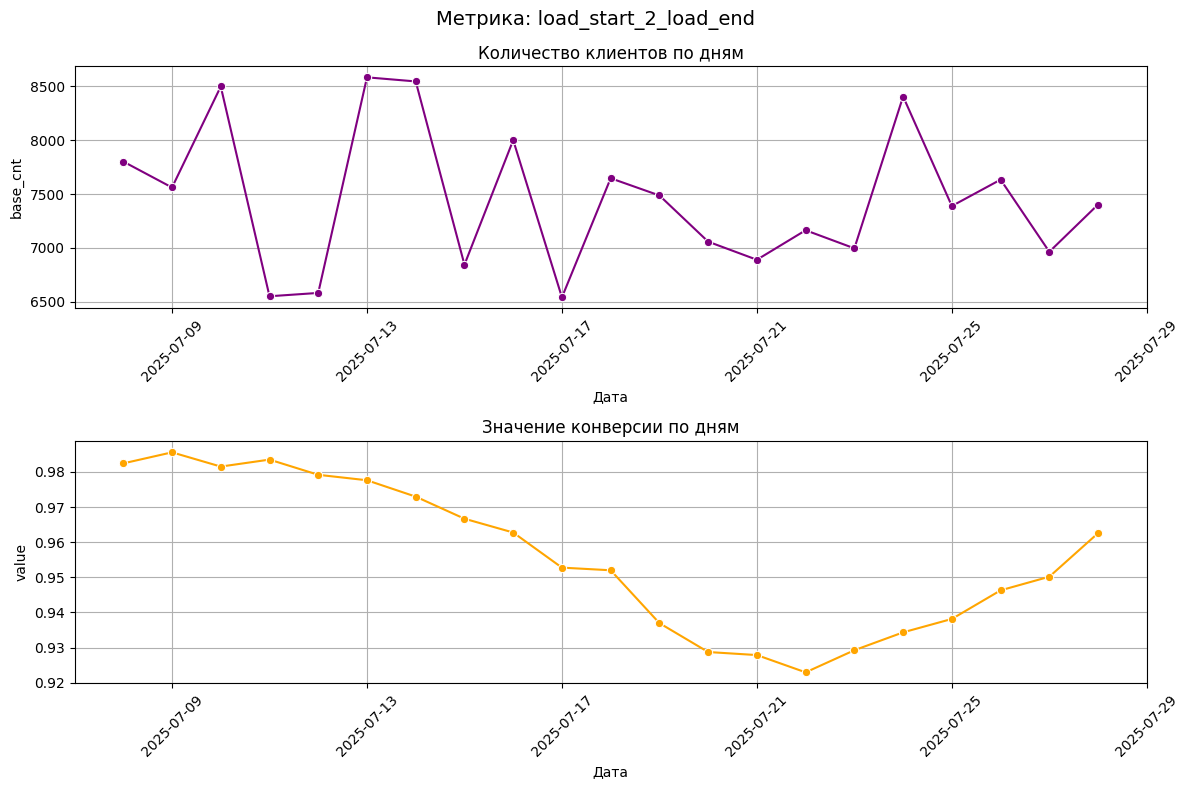

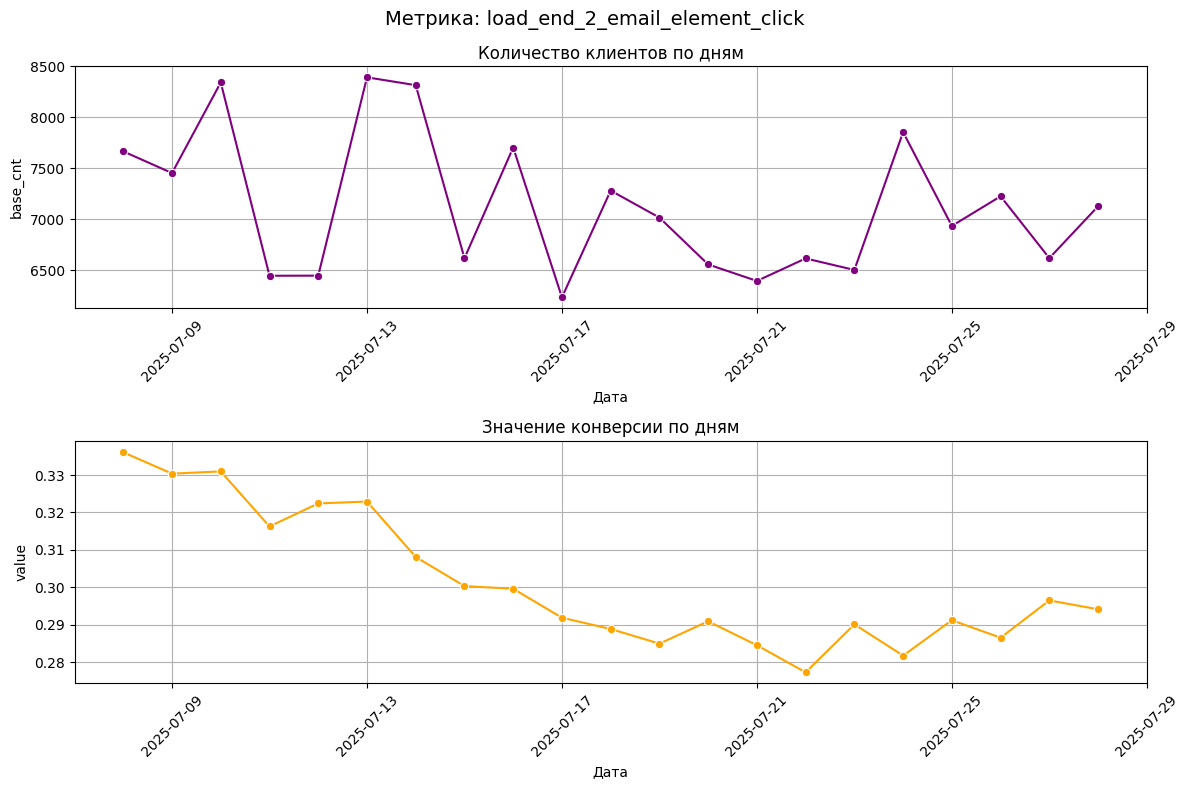

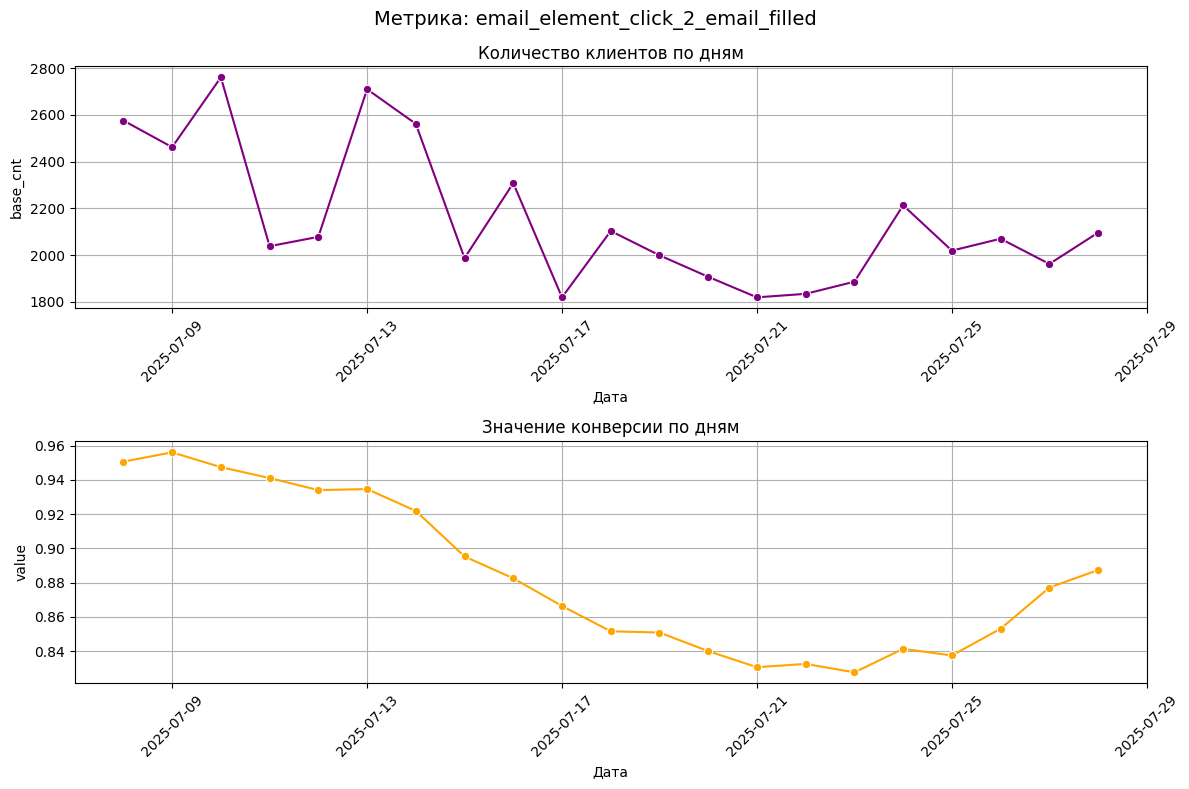

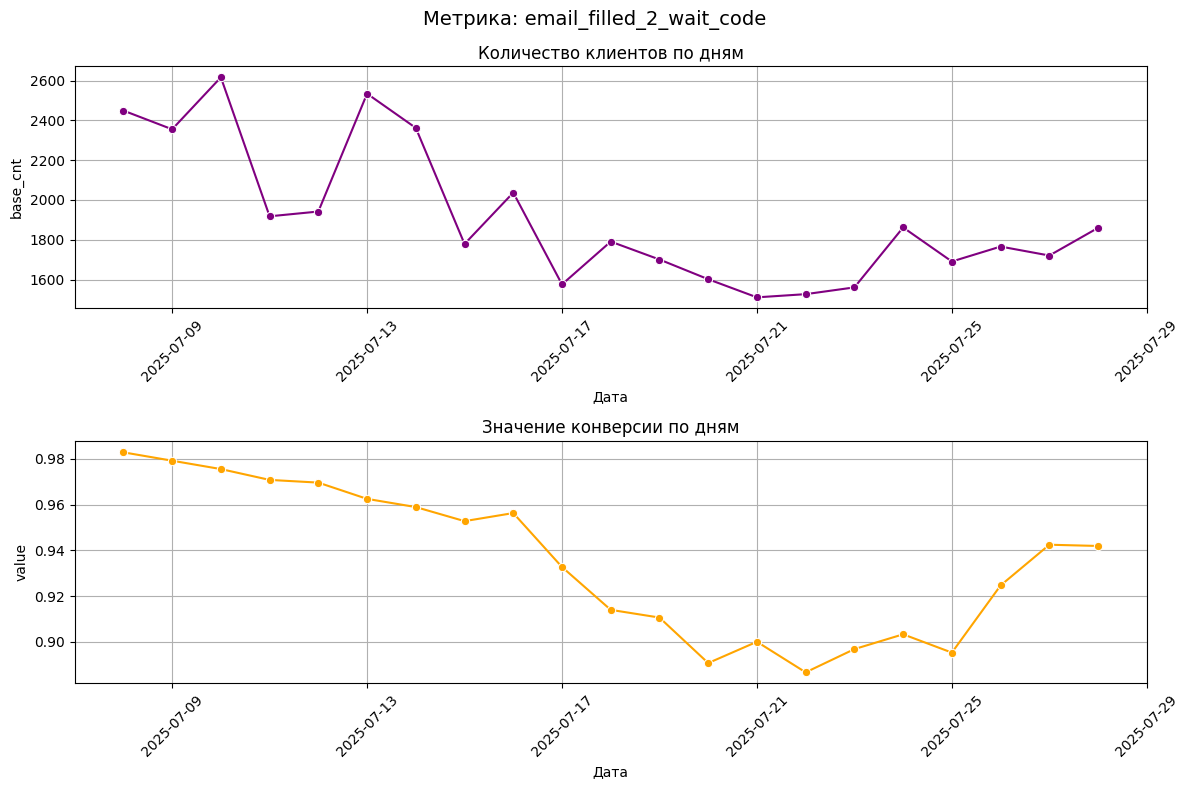

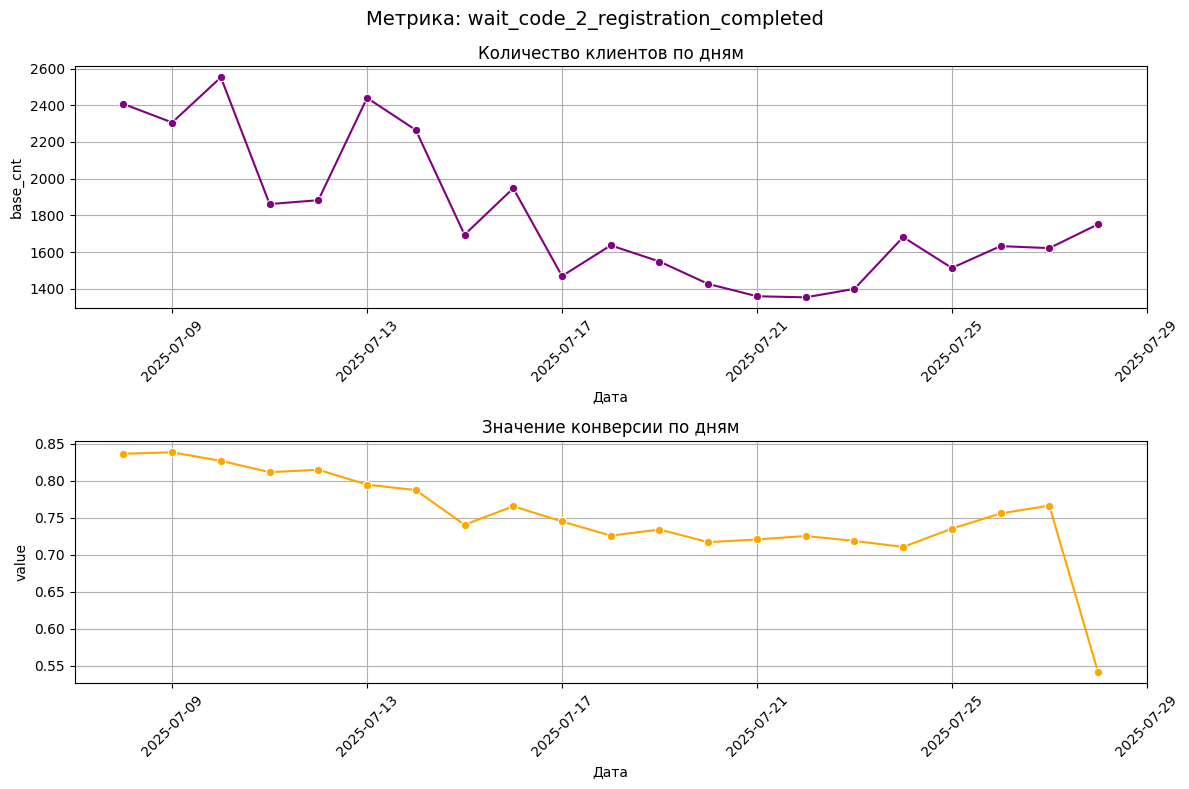

In [33]:
# Уникальные метрики в данных
metrics = conversion_df['metric'].unique()

# Создаем графики для каждой метрики
for metric in metrics:
    # Фильтруем данные по текущей метрике
    df_metric = conversion_df[conversion_df['metric'] == metric]

    # Создаем фигуру с двумя графиками
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'Метрика: {metric}', fontsize=14)

    # График base_cnt по дням
    sns.lineplot(data=df_metric, x='date', y='base_cnt', ax=ax1, marker='o', color='purple')
    ax1.set_title('Количество клиентов по дням')
    ax1.set_xlabel('Дата')
    ax1.grid(True)

    # График value по дням
    sns.lineplot(data=df_metric, x='date', y='value', ax=ax2, marker='o', color='orange')
    ax2.set_title('Значение конверсии по дням')
    ax2.set_xlabel('Дата')
    ax2.grid(True)

    # Поворачиваем даты для лучшей читаемости
    for ax in [ax1, ax2]:
        plt.sca(ax)
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

Как видно из графиков значительное падение конверсии наблюдается только на последнем этапе воронки, когда пользователь ожидает кода подтверждения своего email.  
Детализируем по часам последний этап воронки.

In [17]:
df['hour'] = df['time'].dt.floor('h')

In [18]:
# Отфильтруем последние три дня датасета
df_last_days = df[df.time>'2025-07-26 00:00:00']

In [19]:
metric_1 = 'wait_code'
metric_2 = 'registration_completed'

conv_name = metric_1 + '_2_' + metric_2

join_cols = ['device_id','hour']

base_df = df_last_days[df_last_days['event'] == metric_1][join_cols].drop_duplicates()
target_df = df_last_days[df_last_days['event'] == metric_2][join_cols].drop_duplicates()

base_df['base_cnt'] = 1
target_df['value'] = 1

metric_conv = base_df.merge(target_df,on=join_cols, how ='left').fillna(0)

metric_conv['metric'] = conv_name

metric_conv_agg = metric_conv.groupby(['hour','metric']).agg({'base_cnt':'count','value':'mean'}).reset_index()

In [20]:
metric_conv_agg

,hour,metric,base_cnt,value
0,2025-07-26 00:00:00,wait_code_2_registration_completed,3,0.333333
1,2025-07-26 01:00:00,wait_code_2_registration_completed,1,0.000000
2,2025-07-26 03:00:00,wait_code_2_registration_completed,3,0.666667
3,2025-07-26 05:00:00,wait_code_2_registration_completed,2,0.500000
4,2025-07-26 06:00:00,wait_code_2_registration_completed,15,0.733333
...,...,...,...,...
64,2025-07-28 19:00:00,wait_code_2_registration_completed,155,0.393548
65,2025-07-28 20:00:00,wait_code_2_registration_completed,109,0.330275
66,2025-07-28 21:00:00,wait_code_2_registration_completed,63,0.428571
67,2025-07-28 22:00:00,wait_code_2_registration_completed,45,0.288889


Построим графики. На график с конверсией добавим взвешенное скользящее среднее.

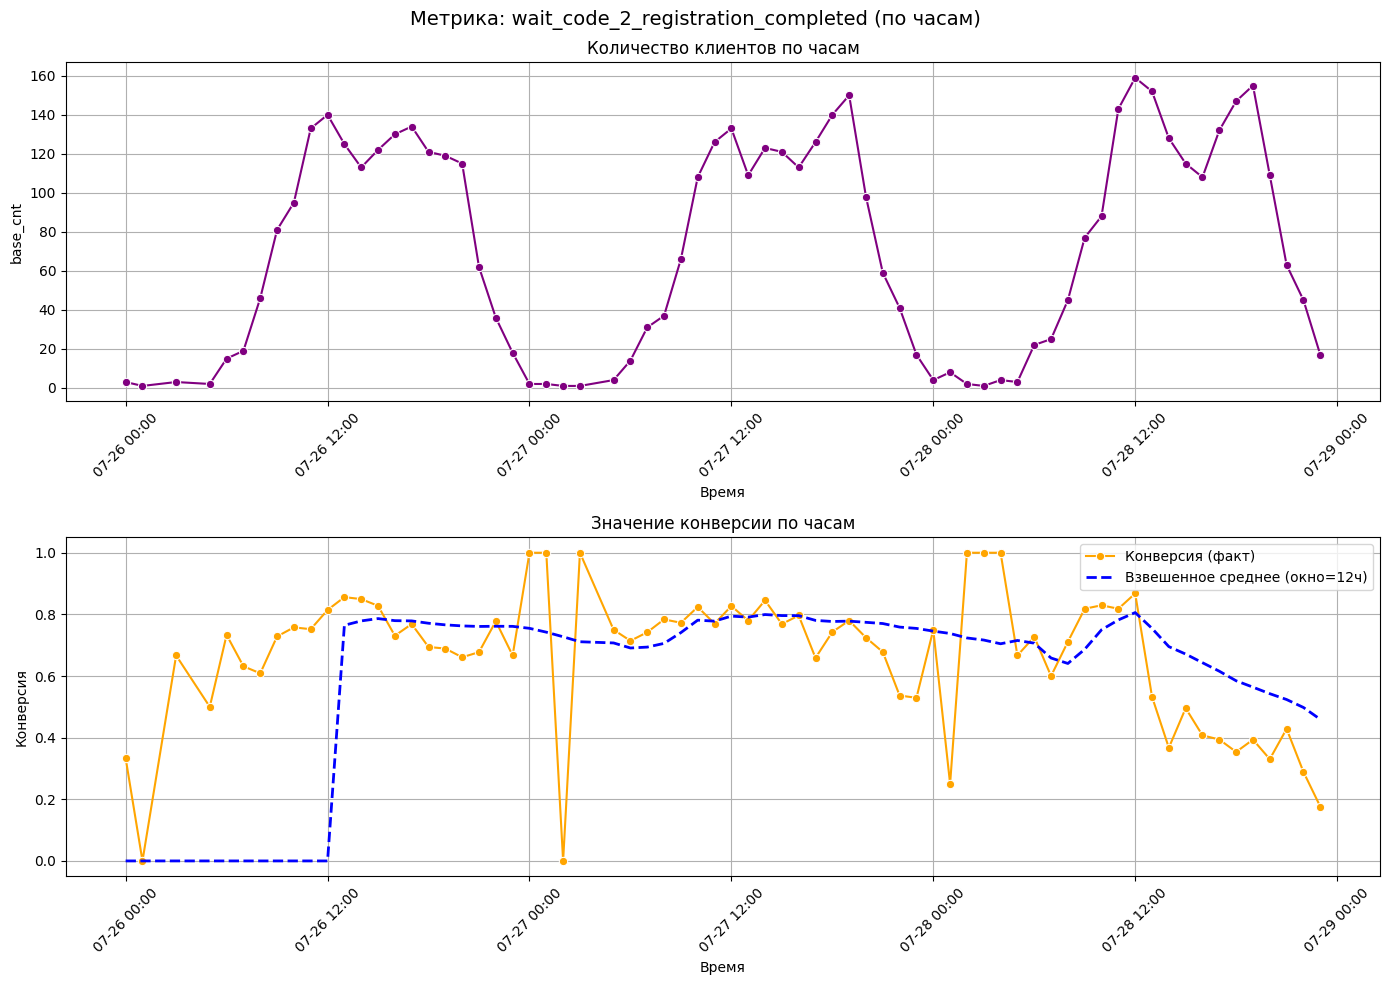

In [32]:
# Создаем фигуру с двумя графиками
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Метрика: wait_code_2_registration_completed (по часам)', fontsize=14)

# График base_cnt по часам
sns.lineplot(data=metric_conv_agg, x='hour', y='base_cnt', ax=ax1, marker='o', color='purple')
ax1.set_title('Количество клиентов по часам')
ax1.set_xlabel('Время')
ax1.grid(True)

# График value по часам с взвешенным скользящим средним
sns.lineplot(data=metric_conv_agg, x='hour', y='value', ax=ax2, marker='o', color='orange', label='Конверсия (факт)')

# Рассчитываем взвешенное скользящее среднее (окно = 12 часов)
window_size = 12
metric_conv_agg['weighted_avg'] = (
    (metric_conv_agg['value'] * metric_conv_agg['base_cnt'])
    .rolling(window=window_size)
    .sum()
    / metric_conv_agg['base_cnt']
    .rolling(window=window_size)
    .sum()
).fillna(0)  # Добавлено заполнение пропусков нулями

sns.lineplot(
    data=metric_conv_agg,
    x='hour',
    y='weighted_avg',
    ax=ax2,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Взвешенное среднее (окно={window_size}ч)'
)

ax2.set_title('Значение конверсии по часам')
ax2.set_xlabel('Время')
ax2.set_ylabel('Конверсия')
ax2.grid(True)
ax2.legend()

# Общее форматирование для обеих осей
date_format = DateFormatter("%m-%d %H:%M")
for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(date_format)
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
metric_conv_agg.tail(12)[['hour', 'value']]

,hour,value
57,2025-07-28 12:00:00,0.867925
58,2025-07-28 13:00:00,0.532895
59,2025-07-28 14:00:00,0.367188
60,2025-07-28 15:00:00,0.495652
61,2025-07-28 16:00:00,0.407407
62,2025-07-28 17:00:00,0.393939
63,2025-07-28 18:00:00,0.353741
64,2025-07-28 19:00:00,0.393548
65,2025-07-28 20:00:00,0.330275
66,2025-07-28 21:00:00,0.428571


#### 3.5 Вывод

Исходя из проведённого анализа, можно сделать вывод, что причиной падения количества регистраций, которое заметили за последние сутки, стал сбой с отправкой пользователю кода подтверждения его электронной почты или же нераспознавание системой введенного кода. Сбой произошёл после 12:00 28.07.2025 г., так как разница в коверсии данного этапа между 12 и 13 часами составляет более 30 процентных пунктов. Для решения проблемы необходимо сообщить в техническую поддержку платформы.